## Intent Classification using TF-IDF + Logistic Regression Goal

<img src="intent_classification.png" alt="Intent Classiication" style="max-width: 100%; height: auto;">

**Goal :** Develop a lightweight natural language processing model that automatically classifies user messages into predefined intent categories, such as greetings, support requests, product inquiries, complaints, and account-related questions.  

**Methodology:**
* Clean and preprocess raw text by removing punctuation, converting text to lowercase, and handling missing values.
* Transform text into numerical features using TF-IDF vectorization.
* Train a Logistic Regression classifier to predict user intent.
* Evaluate performance using accuracy, precision, recall, F1-score, and a confusion matrix.
* Analyze incorrectly classified messages to identify overlapping or ambiguous intent categories.

**Potential Application:**

The model can serve as the intent-detection component of a chatbot, customer-support routing system, or virtual assistant, directing each user request to the appropriate response or business workflow.

TF-IDF : Term Frequency-Inverse Document Frequency

            Utterance
                  ↓
            Text Cleaning
                  ↓
            TF-IDF Vectorizer
                  ↓
            Logistic Regression
                  ↓
            Predicted Intent

In [135]:
# import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib

In [136]:
events = pd.read_csv("digital_assistant_events_dataset.csv")

In [137]:
events = events.copy()

X = events["utterance"]

y = events["intent"]


In [138]:
print(events.shape)

(50000, 21)


In [139]:
print(y.value_counts())

intent
navigation             6995
charging               6501
vehicle_status         6482
climate_control        6138
remote_control         5011
media                  4966
maintenance            4526
general_question       4400
account                2978
roadside_assistance    2003
Name: count, dtype: int64


In [140]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [141]:
# Build the Pipeline
pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1,2),
                min_df=2
            )
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=500,
                random_state=42
            )
        )
    ]
)

In [142]:
# Train the Model
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['account','charging','climate_control',...,'remote_control', 'roadside_assistance','vehicle_status']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of i

In [143]:
# Predit
predictions = pipeline.predict(X_test)

In [144]:
# Evaluate teh Model
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.998


In [145]:
# Precision
precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"Precision: {precision:.3f}")

Precision: 0.998


In [146]:
# Recall
recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"Recall: {recall:.3f}")

Recall: 0.998


In [147]:
# F1 Score
f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"F1 Score: {f1:.3f}")

F1 Score: 0.998


In [148]:
# Classification Report
print(
    classification_report(
        y_test,
        predictions
    )
)

                     precision    recall  f1-score   support

            account       1.00      1.00      1.00       596
           charging       1.00      1.00      1.00      1300
    climate_control       1.00      1.00      1.00      1228
   general_question       0.98      1.00      0.99       880
        maintenance       1.00      1.00      1.00       905
              media       1.00      1.00      1.00       993
         navigation       1.00      1.00      1.00      1399
     remote_control       1.00      1.00      1.00      1002
roadside_assistance       1.00      0.96      0.98       401
     vehicle_status       1.00      1.00      1.00      1296

           accuracy                           1.00     10000
          macro avg       1.00      1.00      1.00     10000
       weighted avg       1.00      1.00      1.00     10000



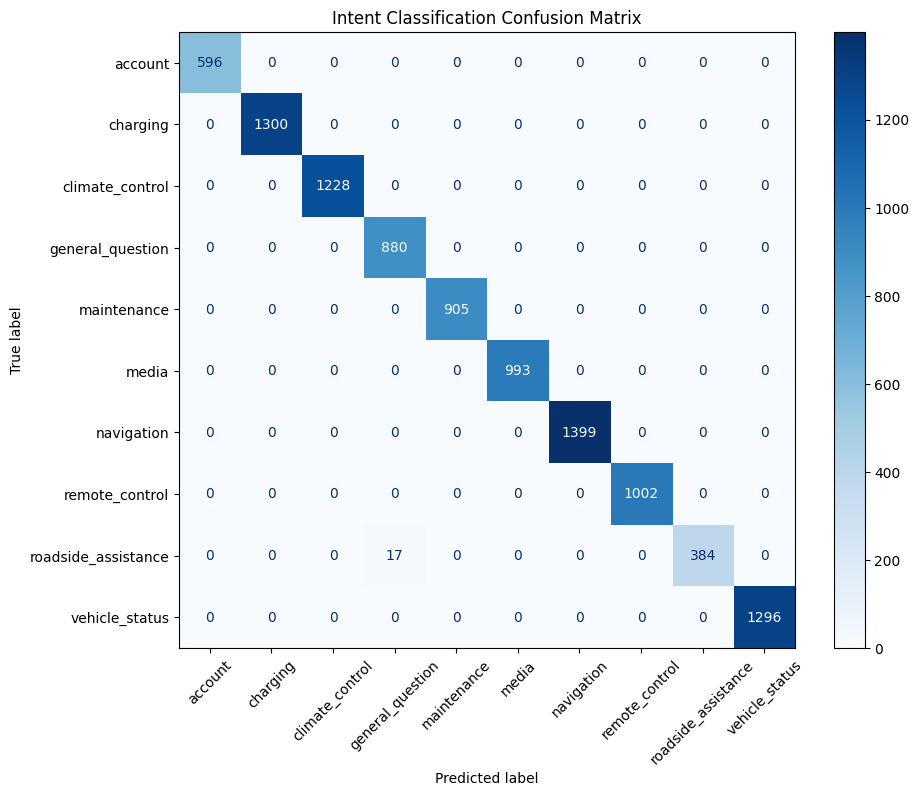

In [149]:
# Confustion Matrix
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

fig, ax = plt.subplots(figsize=(10,8))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("Intent Classification Confusion Matrix")

plt.show()

In [150]:
# Test New Queries
examples = [

    "How much battery do I have?",

    "Navigate to the closest charger",

    "Turn on the air conditioning",

    "Where did I park?",

    "Schedule my next service",

    "Why is charging slow?",

    "Help me log into my account"

]

predictions = pipeline.predict(examples)

pd.DataFrame(
    {
        "Utterance": examples,
        "Predicted Intent": predictions
    }
)

,Utterance,Predicted Intent
0,How much battery do I have?,vehicle_status
1,Navigate to the closest charger,navigation
2,Turn on the air conditioning,climate_control
3,Where did I park?,remote_control
4,Schedule my next service,maintenance
5,Why is charging slow?,charging
6,Help me log into my account,account


In [151]:
# Most Important Words per Intent
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()

clf = pipeline.named_steps["classifier"]

for i, intent in enumerate(clf.classes_):

    top = np.argsort(clf.coef_[i])[-10:]

    print("=" * 60)
    print(intent)

    for idx in reversed(top):
        print(feature_names[idx])

account
account
log
password
update
sign
manage
add
add vehicle
remove vehicle
remove
charging
charging
longer
charger
nearby charger
locate charging
fast
fast charger
pm
10 pm
10
climate_control
hot
cold
cabin
warm
turn
temperature
climate
fan
warm car
defrost windshield
general_question
tell
model
features
tow vehicle
explain
help
vehicle warranty
warranty
new
new update
maintenance
service
maintenance
recalls
battery health
maintenance alerts
dealership
nearby dealership
tires
rotate tires
rotate
media
play
music
song
playing
volume
spotify
open spotify
mute audio
mute
audio
navigation
home
nearest
downtown
route
navigate
traffic
airport
nearest charging
locate ev
ev charger
remote_control
lock
car
unlock
windows
trunk
turn vehicle
locate vehicle
park
did park
stop engine
roadside_assistance
stranded
won
roadside
ran
help
won start
broke
wrong vehicle
wrong
vehicle broke
vehicle_status
fuel
alerts
left
locked
vehicle
warnings
maintenance warnings
lock car
did lock
vehicle health


In [152]:
# Save the Model

joblib.dump(
    pipeline,
    "intent_classifier.pkl"
)

print("Model saved.")


Model saved.


In [153]:
# Load the Model
model = joblib.load("intent_classifier.pkl")

For the prototype, I intentionally started with a lightweight, interpretable baseline. TF-IDF combined with Logistic Regression trains quickly, is easy to explain, and provides a strong benchmark for intent classification. Once the baseline is established, I would compare it against embedding-based approaches such as Sentence Transformers or an LLM-based intent router to determine whether the additional complexity yields meaningful improvements in accuracy, latency, and operational cost.

### Diagnose

In [154]:
print("Total records:", len(events))
print("Unique utterances:", events["utterance"].nunique())

Total records: 50000
Unique utterances: 200


The model is simply memorizing.

In [155]:
events["utterance"].value_counts().head(20)

utterance
Reroute around traffic                  409
Find the nearest charging station       387
How much longer?                        371
Can you take me home?                   367
Navigate to my next appointment         367
Directions to the airport               366
Navigate home                           366
Find parking near my destination        363
How many miles are left?                362
Pause charging                          358
Stop charging                           355
Take me to the nearest grocery store    353
Is there a faster route?                351
When will charging finish?              351
Are the doors locked?                   345
Navigate to Detroit Metro Airport       345
Locate an EV charger                    343
Charging seems slower today             343
Show vehicle health                     341
Find a nearby coffee shop               338
Name: count, dtype: int64

he TF-IDF + Logistic Regression baseline achieved 99.8% accuracy on the synthetic dataset. This was expected because the data contains clean intent labels and limited linguistic variation. In a production environment, I would expand the training corpus with paraphrases, speech-recognition errors, multilingual variants, and unseen phrasings, then compare this baseline against embedding-based classifiers and LLM routing.